# 01 · Exploratory Data Analysis — Credit Card Transactions

**Goal:** understand the data well enough to (1) design features that expose fraud, and
(2) choose an evaluation strategy that reflects how a fraud model is really used.

**Dataset:** 1,296,675 card transactions (Jan 2019 – Jun 2020) from 983 card-holders, 693 merchants,
14 merchant categories, labelled `is_fraud`. It is a synthetic dataset (Sparkov generator) published on
Kaggle, so it contains no real personal data, but it imitates realistic spending and fraud behaviour.

**Questions this notebook answers**
1. How imbalanced is the target? → why accuracy is useless and SMOTE / weighting are needed
2. How do fraudulent amounts differ from normal ones?
3. *When* does fraud happen (hour, weekday, month)?
4. *Where* — which categories, states, distances?
5. *Who* — does age / gender matter?
6. Do the engineered behavioural features (velocity, deviation-from-normal) actually separate fraud?
7. Is there drift over time? → justifies a time-based train / validation / test split

> Run `python -m fraud.train` once first: it builds the cached feature file this notebook loads.

In [1]:
# Standard data / plotting stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Our own package: config (paths, feature lists) and eda (reusable chart functions).
from fraud import config, eda

# Render matplotlib figures inline in the notebook and use a clean style.
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
# Load the cleaned + feature-engineered dataset produced by the pipeline.
# Parquet keeps column types (datetimes, categories) and loads in seconds.
df = pd.read_parquet(config.FEATURES_PARQUET)
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head(3).T

1,296,675 rows x 44 columns


,0,1,2
cc_num,60416207185,60416207185,60416207185
merchant,"Jones, Sawayn and Romaguera",Berge LLC,Luettgen PLC
category,misc_net,gas_transport,gas_transport
amt,7.270,52.940,82.080
gender,F,F,F
city,Fort Washakie,Fort Washakie,Fort Washakie
state,WY,WY,WY
zip,82514,82514,82514
lat,43.005,43.005,43.005
long,-108.896,-108.896,-108.896


## 1. Data quality

In [3]:
# Missing values per column. The only NaNs come from the engineered history features:
# a card's first purchase has no 'previous transaction', so those are expected.
missing = df.isna().sum()
missing[missing > 0].to_frame("missing_rows")

,missing_rows
secs_since_prev_txn,983
km_from_prev_txn,983
speed_kmh_from_prev,983
card_amt_mean_hist,983
card_amt_std_hist,4915
amt_zscore_card,4915
amt_to_card_mean_ratio,983
amt_to_card_cat_mean_ratio,13088


In [4]:
# Basic integrity checks: unique cards / merchants, date coverage, duplicates.
print("cards     :", df[config.CARD_COL].nunique())
print("merchants :", df["merchant"].nunique())
print("categories:", df["category"].nunique())
print("date range:", df[config.TIME_COL].min(), "->", df[config.TIME_COL].max())
print("exact duplicate rows:", df.duplicated().sum())

cards     : 983
merchants : 693
categories: 14
date range: 2019-01-01 00:00:18 -> 2020-06-21 12:13:37


exact duplicate rows: 0


## 2. Class imbalance
Only ~0.58% of transactions are fraud. A model that always answers "legit" would be **99.4% accurate**
and catch nothing. This is why the project uses PR-AUC / recall / precision and rebalances the
training data (SMOTE) or the loss (class weights).

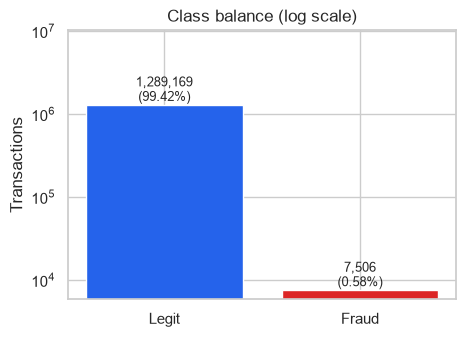

In [5]:
# Bar chart on a log scale: on a linear axis the fraud bar would be invisible.
eda.class_balance(df);

## 3. Transaction amounts

In [6]:
# Summary statistics of the amount, split by class.
df.groupby(config.TARGET)["amt"].describe(percentiles=[.25, .5, .75, .95, .99])

,count,mean,std,min,25%,50%,75%,95%,99%,max
is_fraud,,,,,,,,,,
0,"1,289,169.000",67.667,154.008,1.000,9.610,47.280,82.540,189.900,486.303,"28,948.900"
1,"7,506.000",531.320,390.560,1.060,245.662,396.505,900.875,"1,083.985","1,179.690","1,376.040"


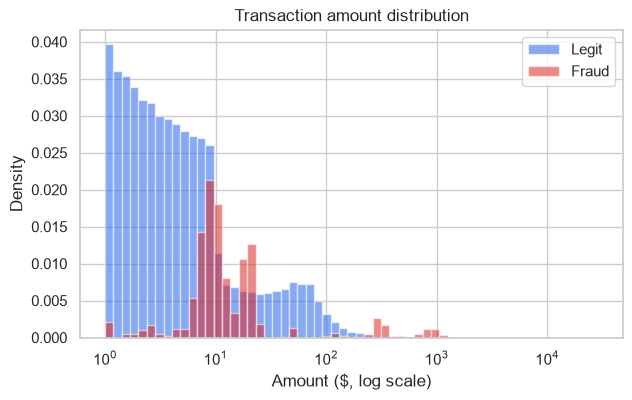

In [7]:
# Distribution on log-spaced bins. Legit spending peaks at small everyday amounts;
# fraud is bimodal: small 'card testing' charges (~$5-50) and large cash-out purchases (~$200-1,300).
eda.amount_distribution(df);

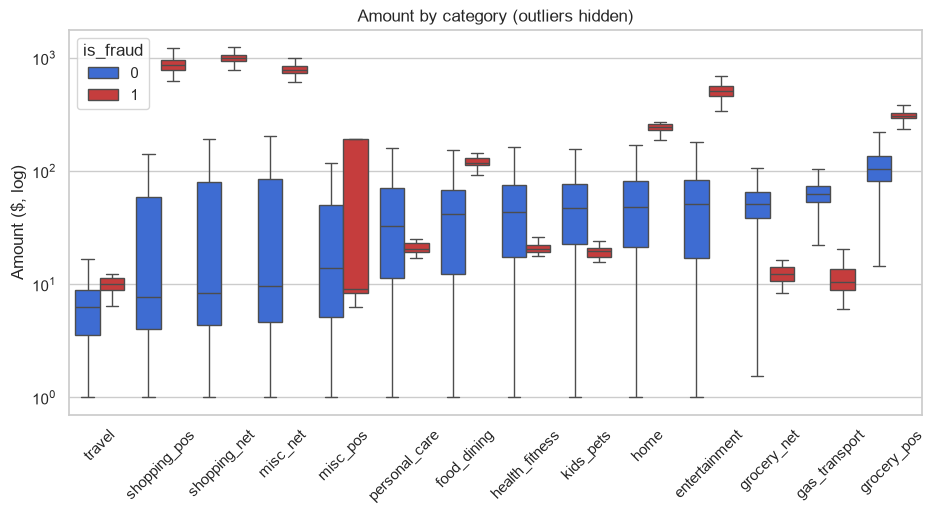

In [8]:
# Amount by category for fraud vs. legit. Fraudsters target categories where large purchases are
# easy to resell (online shopping, grocery POS gift cards) and spend far above normal there.
fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby("category", observed=True)["amt"].median().sort_values().index
sns.boxplot(data=df.sample(300_000, random_state=0), x="category", y="amt", hue=config.TARGET,
            order=order, showfliers=False, ax=ax, palette={0: eda.LEGIT_COLOR, 1: eda.FRAUD_COLOR})
ax.set(yscale="log", title="Amount by category (outliers hidden)", xlabel="", ylabel="Amount ($, log)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="is_fraud");

## 4. When does fraud happen?

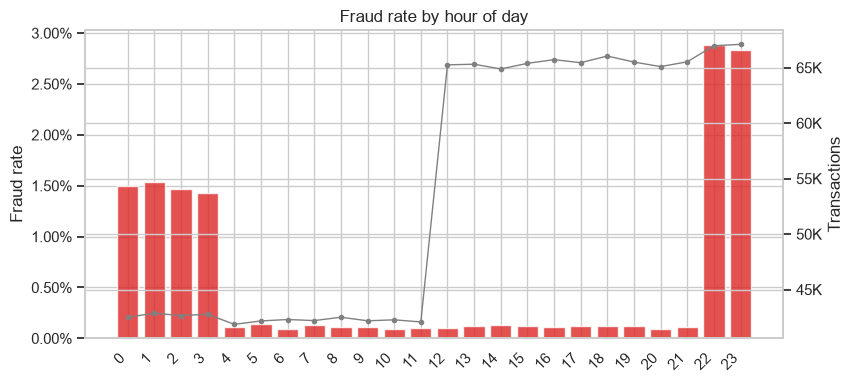

In [9]:
# Fraud rate per hour (bars) with transaction volume (line).
# The fraud rate jumps from ~0.1% in the daytime to ~1.5% (00:00-03:59) and ~2.9% (22:00-23:59)
# -> 'is_night' feature. Volume is lowest exactly when fraud is highest.
eda.fraud_rate_by(df, "hour", "Fraud rate by hour of day");

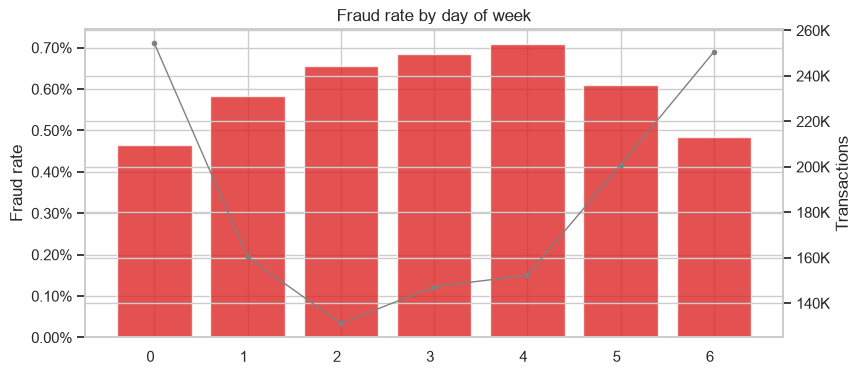

In [10]:
# Day of week (0 = Monday). The effect is much weaker than hour-of-day.
eda.fraud_rate_by(df, "day_of_week", "Fraud rate by day of week");

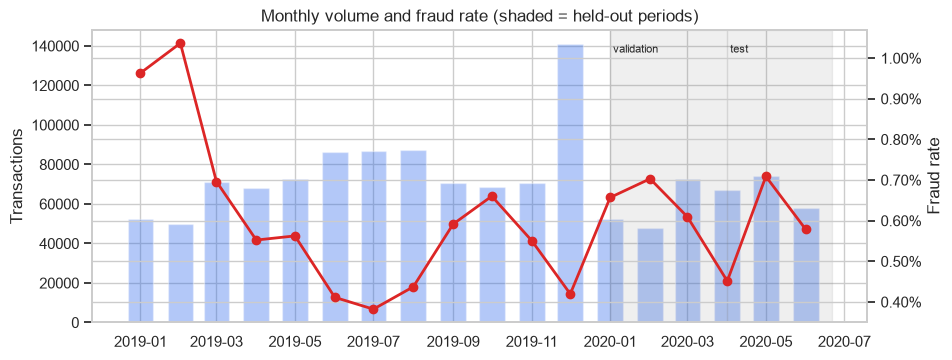

In [11]:
# Monthly trend. Volume has a strong December peak; the fraud RATE drifts month to month.
# Drift is exactly why we split by time: a model must work on future months it has not seen.
eda.monthly_trend(df);

## 5. Where does fraud happen?

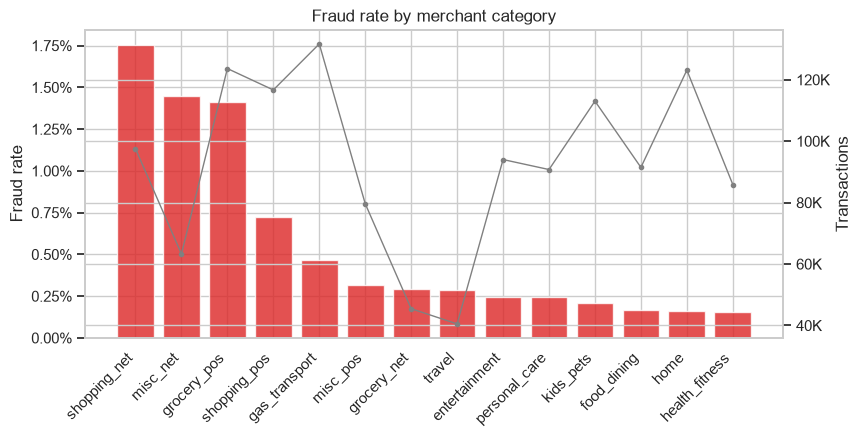

In [12]:
# Category is one of the strongest raw signals: online shopping, misc online and grocery POS
# have 3-10x the average fraud rate.
eda.fraud_rate_by(df, "category", "Fraud rate by merchant category", sort_by_rate=True);

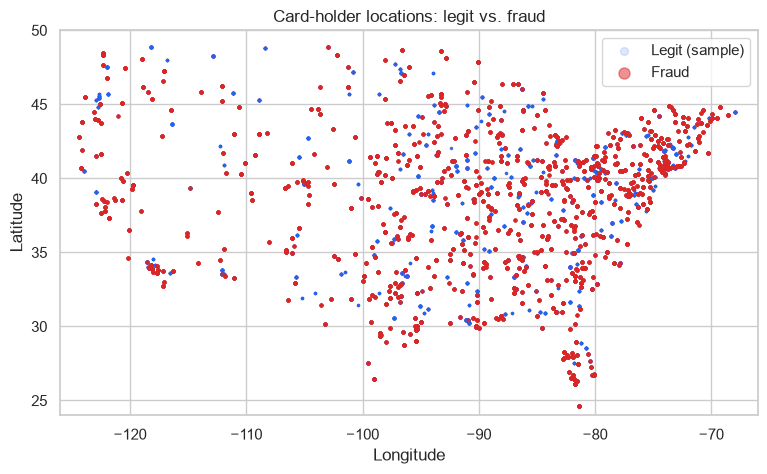

In [13]:
# Geospatial view of card-holder home locations. Fraud is spread across the country — there is
# no single 'fraud state', so location alone is weak; behaviour relative to the card matters more.
eda.fraud_map(df);

In [14]:
# States with enough volume to have a reliable rate (>= 5K transactions), highest fraud rate first.
state = (df.groupby("state", observed=True)[config.TARGET].agg(transactions="size", fraud_rate="mean")
           .query("transactions >= 5000").sort_values("fraud_rate", ascending=False))
state.head(10)

,transactions,fraud_rate
state,,
NV,5607,0.008
CO,13880,0.008
OR,18597,0.008
TN,17554,0.008
NE,24168,0.007
ME,16505,0.007
NH,8278,0.007
OH,46480,0.007
KS,22996,0.007


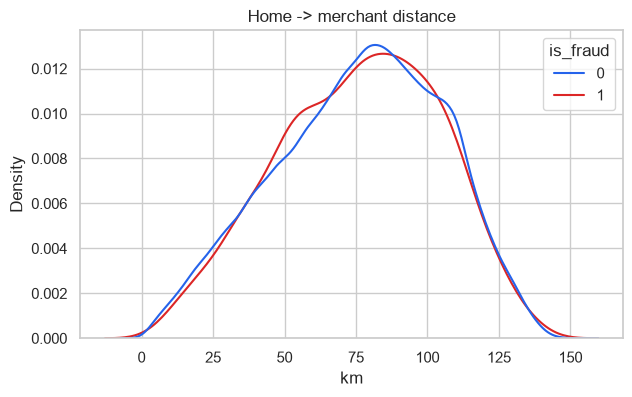

In [15]:
# Distance between home and merchant. In this simulated data merchants are always placed near the
# card-holder, so this distance does NOT separate fraud — a useful negative finding.
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df.sample(200_000, random_state=0), x="cust_merch_dist_km", hue=config.TARGET,
            common_norm=False, palette={0: eda.LEGIT_COLOR, 1: eda.FRAUD_COLOR}, ax=ax)
ax.set(title="Home -> merchant distance", xlabel="km");

## 6. Who is targeted?

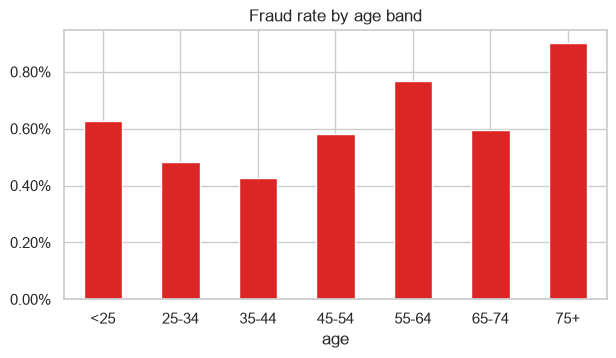

In [16]:
# Fraud rate by age band. U-shaped: highest for 75+ and 55-64, lowest for 35-44.
bands = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 75, 100],
               labels=["<25", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"])
rate = df.groupby(bands, observed=True)[config.TARGET].mean()
ax = rate.plot.bar(color=eda.FRAUD_COLOR, figsize=(7, 3.5), rot=0, title="Fraud rate by age band")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0));

In [17]:
# Gender: a small difference only (men ~0.64% vs women ~0.53%).
df.groupby("gender", observed=True)[config.TARGET].agg(transactions="size", fraud_rate="mean")

,transactions,fraud_rate
gender,,
F,709863,0.005
M,586812,0.006


## 7. Do the engineered features separate fraud?
Raw columns describe a transaction in isolation. The engineered features describe it **relative to the
card's own history** (see `src/fraud/features.py`). Cohen's d below measures, in standard deviations,
how differently each feature behaves for fraud vs. legit.

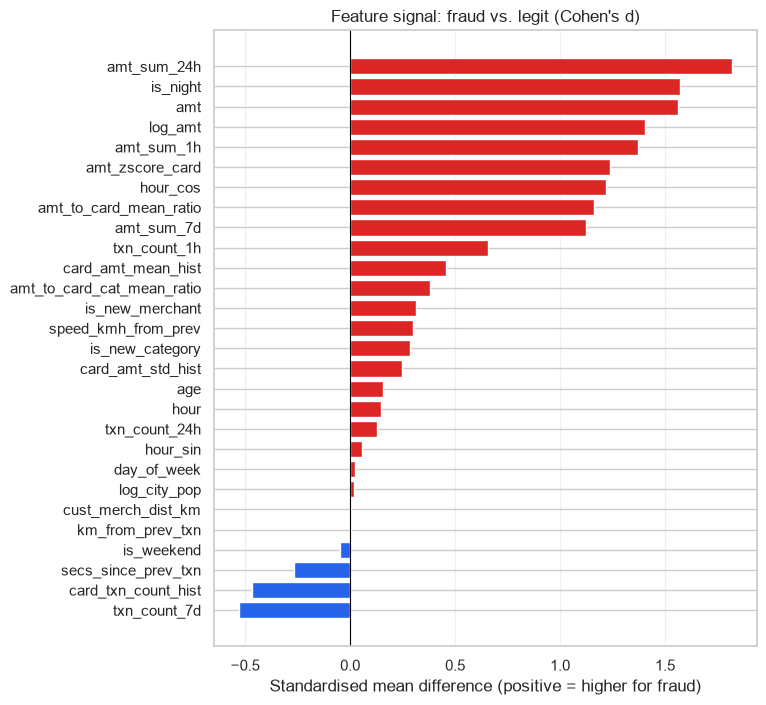

In [18]:
# Positive = higher for fraud. Velocity (amount spent in the last 24h / 7d), deviation from the
# card's normal amount and night-time flags dominate — confirming the feature design.
eda.feature_signal(df);

In [19]:
# Medians side by side make the effect concrete.
cols = ["amt", "txn_count_24h", "amt_sum_24h", "amt_sum_7d", "amt_to_card_mean_ratio",
        "amt_to_card_cat_mean_ratio", "secs_since_prev_txn", "is_night"]
df.groupby(config.TARGET)[cols].median().T.rename(columns={0: "legit (median)", 1: "fraud (median)"})

is_fraud,legit (median),fraud (median)
amt,47.280,396.505
txn_count_24h,4.000,5.000
amt_sum_24h,234.090,"2,242.065"
amt_sum_7d,"1,478.430","3,614.905"
amt_to_card_mean_ratio,0.664,5.230
amt_to_card_cat_mean_ratio,0.821,3.772
secs_since_prev_txn,"16,623.000","4,908.000"
is_night,0.000,1.000


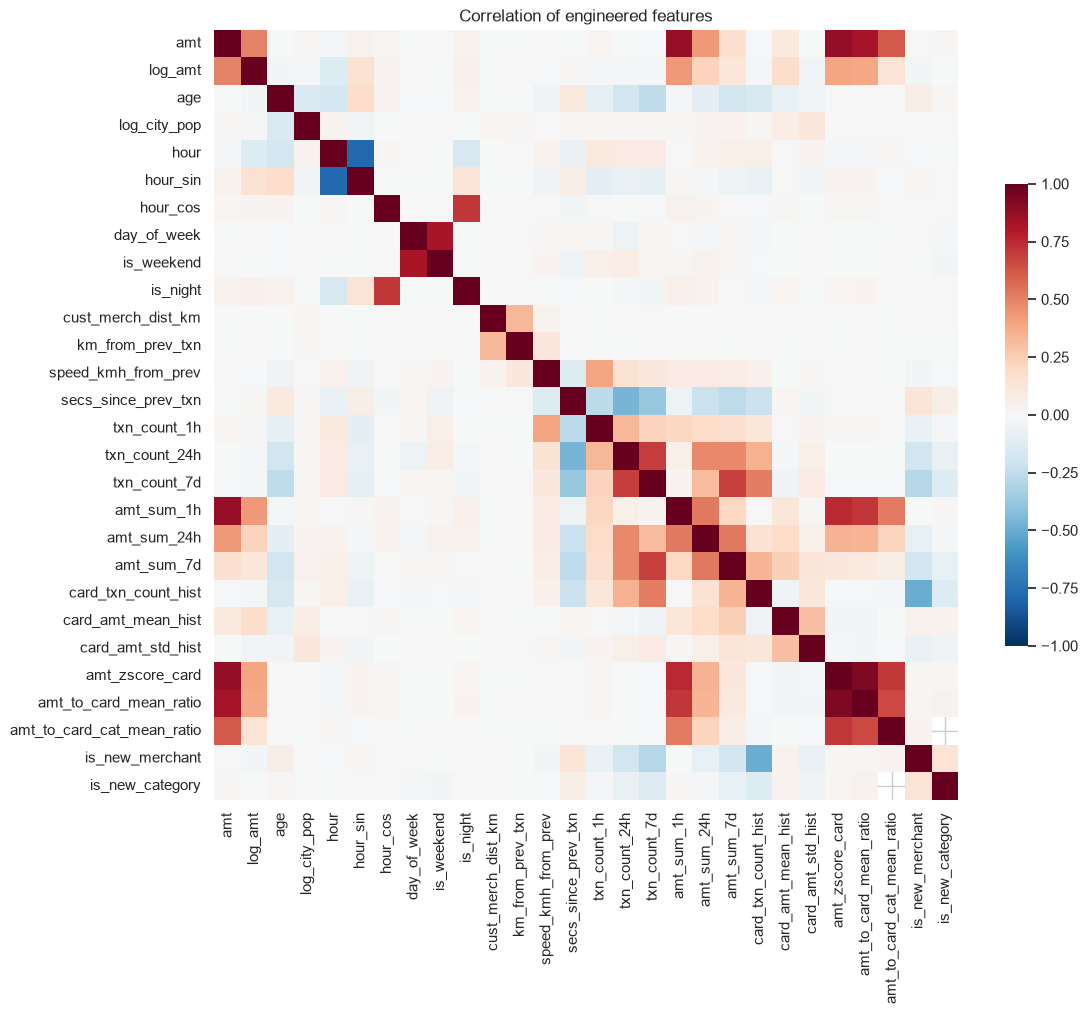

In [20]:
# Correlation between engineered numeric features. Groups of highly correlated features
# (e.g. amt / log_amt, the amt_sum windows) are fine for tree models, and logistic regression
# is regularised, but it is worth knowing they carry overlapping information.
corr = df[config.NUMERIC_FEATURES].sample(200_000, random_state=0).corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": .6})
ax.set_title("Correlation of engineered features");

In [21]:
# A typical fraud episode: one compromised card, transactions around its first fraud.
# Note the burst of high-value purchases in a few hours, at night, in online categories.
card = df.loc[df[config.TARGET] == 1, config.CARD_COL].iloc[0]
first_fraud = df.loc[(df[config.CARD_COL] == card) & (df[config.TARGET] == 1), config.TIME_COL].min()
window = df[(df[config.CARD_COL] == card)
            & df[config.TIME_COL].between(first_fraud - pd.Timedelta(days=2), first_fraud + pd.Timedelta(days=3))]
window[[config.TIME_COL, "category", "amt", "txn_count_24h", "amt_sum_24h", "amt_to_card_mean_ratio", config.TARGET]]

,trans_time,category,amt,txn_count_24h,amt_sum_24h,amt_to_card_mean_ratio,is_fraud
108,2019-02-27 02:01:20,gas_transport,66.930,2,73.070,1.507,0
109,2019-02-27 15:03:28,personal_care,78.090,3,151.160,1.750,0
110,2019-02-28 00:56:10,gas_transport,84.420,3,229.440,1.879,0
111,2019-02-28 08:36:37,grocery_pos,117.600,3,280.110,2.597,0
112,2019-02-28 12:44:42,personal_care,62.400,4,342.510,1.359,0
113,2019-02-28 14:33:03,home,43.250,5,385.760,0.939,0
114,2019-02-28 19:08:26,misc_pos,22.700,5,330.370,0.493,0
115,2019-03-01 01:32:53,gas_transport,13.170,5,259.120,0.287,1
116,2019-03-01 02:42:25,gas_transport,11.740,6,270.860,0.258,1
117,2019-03-01 23:06:58,personal_care,19.160,3,44.070,0.423,1


## 8. Key takeaways → modelling decisions

| Finding | Decision |
|---|---|
| 0.58% fraud — extreme imbalance | Evaluate with PR-AUC / recall / precision; compare **SMOTE** vs class weights vs nothing |
| Fraud is a *burst* on a card: many, large, fast purchases | **Velocity features** (count & sum over 1h / 24h / 7d windows) |
| Fraud amounts are abnormal *for that card* and that category | **Behavioural baseline features** (ratio / z-score vs. card's history) |
| Fraud concentrates at night | `hour`, cyclical `hour_sin/cos`, `is_night` |
| Some categories are 3-10x riskier | `category` one-hot encoded |
| Fraud rate varies with age (U-shaped) | `age` (trees capture non-linear effects) |
| Fraud rate drifts by month | **Time-based split** (train 2019 → validate Q1 2020 → test Q2 2020), never a random split |
| Home-merchant distance carries little signal here | Kept (cheap, realistic in real data) but expected low importance |

Next: `python -m fraud.train` trains and compares the models; results land in `reports/`.